In [7]:
import numpy as np
import matplotlib, timeit
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

## 1. Gaussian Profile
Define a 2D elliptical Gaussian (centered at $\boldsymbol{\mu}$) as:

\begin{equation}
G\left(\textbf{r}|\boldsymbol{\mu}, \Sigma\right) 
    = \frac{F}{2\pi\sqrt{|\Sigma|}}\exp\left(-\frac{1}{2}(\textbf{r} 
    - \boldsymbol{\mu})\cdot\Sigma^{-1}\cdot (\textbf{r} - \boldsymbol{\mu}) \right),
\end{equation}

\begin{equation}
    \Sigma = 
    \begin{bmatrix} 
        I_{xx} &  I_{xy}\\ I_{xy} & I_{yy} 
    \end{bmatrix}; 
    \qquad
    \Sigma^{-1} = \frac{1}{I_{xx}I_{yy} -  I_{xy}I_{xy}}
    \begin{bmatrix} 
        I_{yy} &  -I_{xy}\\ -I_{xy} & I_{xx} \end{bmatrix},
    \end{equation}  

where $I_{xx}$, $I_{yy}$ and $I_{xy}$ are the second moments of the source. 

Some calculations lead to:
\begin{equation}
\begin{aligned}
    I_{xx} &= \frac{1}{2\ln{2}} \left( a^2 \cos^2 \theta + b^2 \sin^2 \theta \right), \\
    I_{xy} &= \frac{1}{2\ln{2}} \left( a^2 - b^2 \right) \sin \theta \cos \theta,  \\
    I_{yy} &= \frac{1}{2\ln{2}} \left( a^2 \sin^2 \theta + b^2 \cos^2 \theta  \right), \\
    I_{xx}I_{yy} - I^2_{xy} & = \frac{a^2 b^2}{4(\ln{2})^2}, \\
    \Sigma & = \frac{1}{2 \ln{2}}
    \begin{bmatrix} 
        a^2 \cos^2 \theta + b^2 \sin^2 \theta &  (a^2 - b^2) \sin \theta \cos \theta \\
        (a^2 - b^2) \sin \theta \cos \theta & a^2 \sin^2 \theta + b^2 \cos^2 \theta 
    \end{bmatrix}, \\
    \Sigma^{-1} & = \frac{2\ln{2}}{a^2 b^2}
    \begin{bmatrix} 
        a^2 \sin^2 \theta + b^2 \cos^2 \theta &  (b^2 - a^2) \sin \theta \cos \theta \\
        (b^2 - a^2) \sin \theta \cos \theta & a^2 \cos^2 \theta + b^2 \sin^2 \theta 
    \end{bmatrix} \\
    |\Sigma| & = \frac{a^2b^2}{4\ln(2)^2}.
\end{aligned}
\end{equation}

where $a, b, \theta$ characterize the ellipse of the FWHM contour. 

## 2. General Form
The general ellipse equation from [wikipedia](https://en.wikipedia.org/wiki/Ellipse#General_ellipse), 
but swapping B and C, and halve C:

$$
A x^2 + B y^2 + 2C x y +  D x +  E y + F = 0
$$
where 

$$
\begin{align}
A & = a^2\sin^2{\theta} +  b^2\cos^2{\theta},  \\
B & = a^2\cos^2{\theta} +  b^2\sin^2{\theta}, \\
C & = (b^2 - a^2)\sin{\theta}\cos{\theta}, \\
D & = -2Ax_0 - 2Cy_0,  \\
E & = -2C x_0 - 2B y_0,  \\
F & = Ax_0^2 + 2C x_0 y_0 + By_0^2 - a^2 b^2. 
\end{align}
$$

## 3. From the above we have
\begin{align}
A & = 2\ln{(2)} I_{xx} \\
B & = 2\ln{(2)} I_{yy} \\
C & = -2\ln{(2)} I_{xy},
\end{align}
We can also calculate D, E, F, given $x_0, y_0$, and noticing that
\begin{equation}
a^2 b^2 =  4\ln(2)^2 |\Sigma|.
\end{equation}

## All the conversions

In [8]:
def ab2cov(p_ab):
    
    a, b, theta, x, y = p_ab
    
    sin = np.sin(np.radians(theta))
    cos = np.cos(np.radians(theta))

    C11 = (a*cos)**2 + (b*sin)**2
    C22 = (a*sin)**2 + (b*cos)**2
    C12 = (a**2 - b**2)*sin*cos
    C21 = C12

    cov = np.array( [[C11, C12], [C21, C22]]) / (2*np.log(2))
    
    ## the inverse matrix
    
    D11 = (a*sin)**2 + (b*cos)**2
    D22 = (a*cos)**2 + (b*sin)**2
    D12 = (b**2 - a**2)*sin*cos
    D21 = D12
    
    cov_inv = 2*np.log(2)* np.array( [[D11, D12], [D21, D22]]) / (a*b)**2
    
    return cov, cov_inv    

def cov2AB(cov, x0, y0):

    A = 2*np.log(2) * cov[0,0]
    B = 2*np.log(2) * cov[1,1]
    C = -2*np.log(2) * cov[0,1]

    D = -2*A*x0 - 2*C*y0
    E = -2*C*x0 - 2*B*y0
    F = A*x0**2 + 2*C*x0*y0 + B*y0**2 - 4*np.log(2)**2*np.linalg.det(cov)

    p_AB = [A, B, C, D, E, F]
    
    return p_AB

def ellipse_equation_general(p_AB, x, y):
    
    A, B, C, D, E, F = p_AB
    
    return A*x**2 + B*y**2 + 2*C*x*y + 2*D*x + 2*E*y + F

def ab2AB(p_ab):
    
    a, b, theta, x0, y0 = p_ab
    
    ### a, b, in any length units; theta in degrees ###
    sin = np.sin(np.radians(theta))
    cos = np.cos(np.radians(theta))
    
    A = (a*sin)**2 + (b*cos)**2
    B = (a*cos)**2 + (b*sin)**2
    C = (b**2 - a**2)*sin*cos
    D = -2*A*x0 - 2*C*y0
    E = -2*C*x0 - 2*B*y0
    F = A*x0**2 + C*x0*y0 + B*y0**2 - (a*b)**2
    
    return [A, B, C, D, E, F]

def AB2ab(p_AB, convention='AC2017'):
    ## converting general parameters (AC2017 convention or wikipedia convention) to ab parameters.

    A, B, C, D, E, F = p_AB
    
    if convention=='AC2017':
        ## AC2017 params to wiki params
        B, C = 2*C, B
    
    ## wiki AB params to a, b, theta
    Delta = B*B - 4*A*C
    
    f1 = A*E*E + C*D*D - B*D*E + F*Delta
    f2 = np.sqrt( (A-C)**2 + B**2)
    
    a = -np.sqrt(2 * f1 * ( A+C+f2) ) / Delta
    b = -np.sqrt(2 * f1 * ( A+C-f2) ) / Delta
    
    x0 = (2*C*D - B*E) / Delta
    y0 = (2*A*E - B*D) / Delta
    
    if B==0:
        if A < C:
            theta = 0
        else:
            theta = 90
    else:
        theta = np.degrees(np.arctan( (C - A - f2) / B ))

    theta = 90 - theta
    p_ab = [a, b, theta, x0, y0]
    
    return p_ab


## Set up randomly placed ellipses

In [9]:
def set_random_pair(center_on_ell1=False):
    
    if center_on_ell1:
        x1, y1 = 0, 0
        theta1 = 0
    else:
        x1, y1 = np.random.uniform(-2,2,2)  ## center of ellipse 1
        theta1 = np.random.uniform(0, 180)  ## in degrees
        
    a1, b1 = np.random.uniform(1,3,2)
    if b1 > a1:
        a1, b1 = b1, a1

    x2, y2 = np.random.uniform(-2,2,2)  ## center of ellipse 2
    a2, b2 = np.random.uniform(0.5,2,2)
    theta2 = np.random.uniform(0, 180)  ## in degrees
    if b2 > a2:
        a2, b2 = b2, a2

    p1_ab = [a1, b1, theta1, x1, y1]
    p2_ab = [a2, b2, theta2, x2, y2]

    return p1_ab, p2_ab


## blended shape

In [10]:
def calc_bl_shape(cov1, cov2, F1, F2, mu1, mu2):

    Ixx1, Iyy1, Ixy1 = cov1[0,0], cov1[1,1], cov1[0,1]
    Ixx2, Iyy2, Ixy2 = cov2[0,0], cov2[1,1], cov2[0,1]

    Ixx = (Ixx1*F1 + Ixx2*F2)/(F1+F2) + mu1**2*F1*F2/(F1+F2)**2
    Iyy = (Iyy1*F1 + Iyy2*F2)/(F1+F2) + mu2**2*F1*F2/(F1+F2)**2
    Ixy = (Ixy1*F1 + Ixy2*F2)/(F1+F2) + mu1*mu2*F1*F2/(F1+F2)**2

    cov = np.array([[Ixx, Ixy],[Ixy, Iyy]])
    
    return cov

## plotting function

In [11]:
def Ell_Gaussian(x, y, Cov):
    
    ## Gaussian without normalization factors; peak value is 1 at origin
    
    Cov_inv = np.linalg.inv(Cov)
    
    C11 = Cov_inv[0][0]
    C12 = Cov_inv[0][1]
    C21 = Cov_inv[1][0]
    C22 = Cov_inv[1][1]
    
    prod = C11*x*x + C12*x*y + C21*x*y + C22*y*y
    
    return np.exp(-prod/2)

def plot_contour(Cov, x0, y0, level=[0], c='b', ls='-', rough_size=10, ax=None):
    
    x = np.linspace(-rough_size, rough_size, 100)
    y = np.linspace(-rough_size, rough_size, 100)
    x, y = np.meshgrid(x,y)
 
    z = Ell_Gaussian(x-x0, y-y0, Cov)
    
    ax.contour(x, y, z, level, colors=c, linestyles=ls)

## Visual check

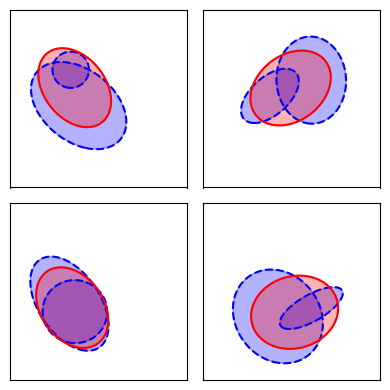

In [23]:
F1 = 1
F2 = 1

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(4,4))

for i, ax in enumerate(axes.ravel()):

    p1_ab, p2_ab = set_random_pair()

    a1, b1, theta1, x1, y1 = p1_ab
    a2, b2, theta2, x2, y2 = p2_ab

    cov1, cov_inv1 = ab2cov(p1_ab)
    cov2, cov_inv2 = ab2cov(p2_ab)

    p1_AB = cov2AB(cov1, x1, y1)
    p2_AB = cov2AB(cov2, x2, y2)

    mu1, mu2 = x2-x1, y2-y1
    cov_bl = calc_bl_shape(cov1, cov2, F1=F1, F2=F2, mu1=mu1, mu2=mu2)
    
    x_c, y_c = mu1*F2/(F1+F2) + x1, mu2*F2/(F1+F2) + y1
    p_AB_bl = cov2AB(cov_bl, x_c, y_c)
    p_ab_bl = AB2ab(p_AB_bl)
    
    a3, b3, theta3, x3, y3 = p_ab_bl


    plot_contour(cov1, x1, y1, level=[0.5], ls='--', rough_size = 2*a3, ax=ax)
    plot_contour(cov2, x2, y2, level=[0.5], ls='--', rough_size = 2*a3, ax=ax)
    plot_contour(cov_bl, x3, y3, level=[0.5], c='r', rough_size = 2*a3, ax=ax)

    #### fill body color ####
    if 1:
        ellipse1 = Ellipse((x1,y1), width=2*a1, height=2*b1, angle=theta1, facecolor='b', edgecolor='k', alpha=0.3, linewidth=1)
        ellipse2 = Ellipse((x2,y2), width=2*a2, height=2*b2, angle=theta2, facecolor='b', edgecolor='k', alpha=0.3, linewidth=1)
        ellipse3 = Ellipse((x3,y3), width=2*a3, height=2*b3, angle=theta3, facecolor='r', edgecolor='k', alpha=0.3, linewidth=1)
        ax.add_artist(ellipse1)
        ax.add_artist(ellipse2)
        ax.add_artist(ellipse3)
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-4,4)
    ax.set_ylim(-4,4)
    ax.axis('equal')

plt.tight_layout()